# Methods for Grouping Blockchain Participants Based on Open Data

Этот проект является практической частью выпускной квалификационной работы.
Разработан высокопроизводительный пайплайн для кластеризации кошельков Bitcoin на GPU.

## Технологический стек
* **GPU:** NVIDIA Tesla T4
* **RAPIDS:** cuDF, cuML (ускорение до 50x по сравнению с CPU)
* **Algorithms:** K-Means (макро-сегментация), DBSCAN (поиск аномалий), PCA (визуализация).

## Как запустить
1. Откройте ноутбук в Google Colab.
2. Включите аппаратный ускоритель (GPU T4).
3. Запустите ячейку установки RAPIDS.
4. Загрузите файл `bitcoin_clustered_users.csv`.

## Результаты
Алгоритм успешно выделил 4 основных сегмента сети и обнаружил скрытые
автоматизированные структуры внутри кластера крупных узлов.

In [14]:
!pip install cudf-cu12 cuml-cu12 cugraph-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import cudf
import time

path_part1 = '/content/drive/MyDrive/Thesis_Data/blockchain_dataset_10k.csv'
path_part2 = '/content/drive/MyDrive/Thesis_Data/blockchain_dataset_part2.csv'

print("Загрузка данных в VRAM видеокарты...")
start_time = time.time()

df1 = cudf.read_csv(path_part1)
df2 = cudf.read_csv(path_part2)

df_full = cudf.concat([df1, df2], ignore_index=True)

del df1
del df2

end_time = time.time()

print("=" * 40)
print(f"Слияние завершено за {round(end_time - start_time, 2)} секунд!")
print(f"Всего строк в таблице: {len(df_full)}")
print("=" * 40)

display(df_full.head())

Загрузка данных в VRAM видеокарты...
Слияние завершено за 2.97 секунд!
Всего строк в таблице: 9541182


,BlockHeight,Time,TxID,Type,Address,Amount_BTC
0,200000,2012-09-22 14:45:59,dbaf14e1c476e76ea05a8b71921a46d6b06f0a950f17c5...,COINBASE,New_Coins,0.000000
1,200000,2012-09-22 14:45:59,dbaf14e1c476e76ea05a8b71921a46d6b06f0a950f17c5...,OUTPUT,Non-standard,50.635175
2,200000,2012-09-22 14:45:59,ee475443f1fbfff84ffba43ba092a70d291df233bd1428...,INPUT,1CfD77hupeUvFwBPxZ2fA8iyWmVwQY22oh,102.120000
3,200000,2012-09-22 14:45:59,ee475443f1fbfff84ffba43ba092a70d291df233bd1428...,OUTPUT,1FhNPRh1TxVidoKkWFEpdmK5RXw9vG1KUb,55.860000
4,200000,2012-09-22 14:45:59,ee475443f1fbfff84ffba43ba092a70d291df233bd1428...,OUTPUT,1QE7Tazy1uHD1utCb1fCW6aLF3RZ1sNwd2,46.260000


In [17]:
import time

print("Очистка данных...")
start_time = time.time()

df_clean = df_full[
    (df_full['Type'] != 'COINBASE') &
    (df_full['Address'] != 'Unknown') &
    (df_full['Address'] != 'ParseError') &
    (df_full['Address'] != 'Non-standard')
]

df_clean = df_clean.dropna()

end_time = time.time()

print("=" * 40)
print(f"Очистка завершена за {round(end_time - start_time, 2)} секунд!")
print(f"Строк ДО очистки:    {len(df_full)}")
print(f"Строк ПОСЛЕ очистки: {len(df_clean)}")
print(f"Удалено мусора:      {len(df_full) - len(df_clean)} строк")
print("=" * 40)

Очистка данных...
Очистка завершена за 0.2 секунд!
Строк ДО очистки:    9541182
Строк ПОСЛЕ очистки: 9310736
Удалено мусора:      230446 строк


In [18]:
import time

print("Оптимизированное построение графа (Star-Graph метод)...")
start_time = time.time()

df_in = df_clean[df_clean['Type'] == 'INPUT'][['TxID', 'Address']].reset_index(drop=True)

tx_counts = df_in['TxID'].value_counts().reset_index()
tx_counts.columns = ['TxID', 'count']

multi_txs = tx_counts[tx_counts['count'] > 1][['TxID']]

df_multi = df_in.merge(multi_txs, on='TxID', how='inner')

first_addresses = df_multi.groupby('TxID').nth(0).reset_index()
first_addresses = first_addresses.rename(columns={'Address': 'First_Address'})

edges = df_multi.merge(first_addresses, on='TxID', how='inner')

edges_unique = edges[edges['Address'] != edges['First_Address']][['Address', 'First_Address']]

edges_unique = edges_unique.drop_duplicates()

end_time = time.time()

print("=" * 40)
print(f"Эвристика отработала за {round(end_time - start_time, 2)} секунд!")
print(f"Найдено уникальных связей (ребер графа): {len(edges_unique)}")
print("=" * 40)

display(edges_unique.head())

Оптимизированное построение графа (Star-Graph метод)...
Эвристика отработала за 0.83 секунд!
Найдено уникальных связей (ребер графа): 957606


,Address,First_Address
0,169PuJjXLK7FA9qcgRiLpNH2HPFMet9t4X,1G7jDsAShoyPcDDCrxie9NBjCvoEMwXsas
1,1HfXfNucFPtp8GNQbDc8HcADtaaPrSNZK6,1G7jDsAShoyPcDDCrxie9NBjCvoEMwXsas
2,1ES7ZByGYdekmfyTV1toYCy58cvkR73bEg,1G7jDsAShoyPcDDCrxie9NBjCvoEMwXsas
3,1PBib2HKb74ALfKfEy9i6WRkwLyPooTwpe,1G7jDsAShoyPcDDCrxie9NBjCvoEMwXsas
4,19qAkSQjdhKSCybWUnqmd8VP6HGwZ9hhXx,1G7jDsAShoyPcDDCrxie9NBjCvoEMwXsas


In [19]:
import cugraph
import time

print("Строим граф и ищем кошельки пользователей (Connected Components)...")
start_time = time.time()

G = cugraph.Graph(directed=False)

G.from_cudf_edgelist(edges_unique, source='Address', destination='First_Address')

components = cugraph.weakly_connected_components(G)

components = components.rename(columns={'vertex': 'Address', 'labels': 'Wallet_ID'})

end_time = time.time()

print("=" * 40)
print(f"Граф проанализирован за {round(end_time - start_time, 2)} секунд!")
print(f"Всего адресов объединено: {len(components)}")
print(f"Уникальных пользователей (кошельков) найдено: {components['Wallet_ID'].nunique()}")
print("=" * 40)

display(components.head(10))

Строим граф и ищем кошельки пользователей (Connected Components)...
Граф проанализирован за 0.31 секунд!
Всего адресов объединено: 851961
Уникальных пользователей (кошельков) найдено: 80599


,Wallet_ID,Address
0,40,1NW7xj9wUVqiEUn4UkAPrPqQVuofRqE4Hw
1,156236,15pCqarMAy89cbPdHWJ3RHiUvF52tTiptm
2,665540,1Jorkk5wsRhESPwmVsvPJ7aYf22sL64F4H
3,58,19GvbXaUL8rWWShsjfJG91PPmCFbocksKg
4,9,1Lv3n5DBhG5VAaLKh5r2kosuMeRrqYtu4R
5,758466,14wg4iHsAkTmN45r9aKTPKsKFub9v8kbJx
6,795123,1FrgURSAMwYmYhV3LPyZQqYXqN1bhT7AMi
7,227655,1Ppp7DYpeydrUvXQMxnLuvrLVukicoU8hY
8,245841,1BbrWhhqWKss9kmWEPjnjqAcpbnBH5vdNo
9,459069,14PcbQyRjsXjfqh8LXp5cBLc4PXHYvBJmf


In [20]:
import cudf
import time

print("Начинаем Feature Engineering (Финальная GPU-версия)...")
start_time = time.time()

unique_addresses = df_clean[['Address']].drop_duplicates().reset_index(drop=True)

address_map = unique_addresses.merge(components, on='Address', how='left')

null_mask = address_map['Wallet_ID'].isnull()
num_missing = null_mask.sum()

max_id = address_map['Wallet_ID'].fillna(0).max()
start_val = int(max_id) + 1

new_ids = cudf.Series(range(start_val, start_val + num_missing), index=address_map[null_mask].index)

address_map.loc[null_mask, 'Wallet_ID'] = new_ids

df_merged = df_clean.merge(address_map, on='Address', how='left')

receives = df_merged[df_merged['Type'] == 'OUTPUT'].groupby('Wallet_ID').agg({
    'Amount_BTC': 'sum',
    'TxID': 'count'
}).reset_index()
receives.columns = ['Wallet_ID', 'Total_Received_BTC', 'Num_Receives']

spends = df_merged[df_merged['Type'] == 'INPUT'].groupby('Wallet_ID').agg({
    'Amount_BTC': 'sum',
    'TxID': 'count'
}).reset_index()
spends.columns = ['Wallet_ID', 'Total_Spent_BTC', 'Num_Spends']

user_profiles = receives.merge(spends, on='Wallet_ID', how='outer').fillna(0)

user_profiles['Total_Tx'] = user_profiles['Num_Receives'] + user_profiles['Num_Spends']

end_time = time.time()

print("=" * 40)
print(f"Профили пользователей созданы за {round(end_time - start_time, 2)} секунд!")
print(f"Всего уникальных сущностей (кошельков): {len(user_profiles)}")
print("=" * 40)

display(user_profiles.sort_values('Total_Tx', ascending=False).head(10))

Начинаем Feature Engineering (Финальная GPU-версия)...
Профили пользователей созданы за 0.47 секунд!
Всего уникальных сущностей (кошельков): 773816


,Wallet_ID,Total_Received_BTC,Num_Receives,Total_Spent_BTC,Num_Spends,Total_Tx
545948,6073,1.604525e+06,1184504,1.604279e+06,1184360,2368864
183367,9,1.365304e+06,93870,1.766664e+06,122229,216099
465185,40,2.830341e+05,81968,2.838805e+05,82043,164011
656730,58,1.189179e+06,79430,1.227663e+06,78866,158296
486835,779268,1.955614e+04,32958,1.955614e+04,32958,65916
344328,21,3.059859e+05,31791,3.030662e+05,31906,63697
240407,501448,3.765335e+04,30634,3.765336e+04,30842,61476
672070,34,1.567236e+04,28300,1.562388e+04,28414,56714
551650,133,1.068318e+04,24252,1.028689e+04,24939,49191
463656,108765,7.326188e+04,23542,7.328183e+04,23580,47122


In [21]:
import cupy as cp
import cudf
from cuml.preprocessing import StandardScaler
from cuml.cluster import KMeans
import time

print("Запускаем Машинное Обучение: K-Means на GPU...")
start_time = time.time()

features = ['Total_Received_BTC', 'Num_Receives', 'Total_Spent_BTC', 'Num_Spends', 'Total_Tx']
X = user_profiles[features].copy()

for col in features:
    X[col] = cp.log1p(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

user_profiles['Cluster'] = kmeans.labels_

end_time = time.time()
print("=" * 40)
print(f"✅ K-Means обучен за {round(end_time - start_time, 2)} секунд!")
print("=" * 40)

cluster_stats = user_profiles.groupby('Cluster').agg({
    'Wallet_ID': 'count',
    'Total_Received_BTC': 'mean',
    'Total_Tx': 'mean'
}).reset_index()

cluster_stats.columns = ['Cluster_ID', 'Number_of_Users', 'Avg_Received_BTC', 'Avg_Transactions']

display(cluster_stats.sort_values('Avg_Transactions', ascending=False))

Запускаем Машинное Обучение: K-Means на GPU...
✅ K-Means обучен за 0.46 секунд!


,Cluster_ID,Number_of_Users,Avg_Received_BTC,Avg_Transactions
0,1,9910,1279.529446,705.855499
3,3,17633,10.407844,25.727103
1,2,89520,57.463231,7.010769
2,0,656753,182.043682,1.879638


In [22]:
from cuml.cluster import DBSCAN
import cupy as cp

print("Этап 2: Ищем аномалии внутри 'Китов' с помощью DBSCAN...")
start_time = time.time()

target_cluster = 3
df_target = user_profiles[user_profiles['Cluster'] == target_cluster].copy().reset_index(drop=True)

features = ['Total_Received_BTC', 'Num_Receives', 'Total_Spent_BTC', 'Num_Spends', 'Total_Tx']
X_target = df_target[features].copy()

for col in features:
    X_target[col] = cp.log1p(X_target[col])

scaler_db = StandardScaler()
X_scaled_target = scaler_db.fit_transform(X_target)

dbscan = DBSCAN(eps=0.5, min_samples=15)
df_target['SubCluster'] = dbscan.fit_predict(X_scaled_target)

end_time = time.time()

print("=" * 40)
print(f"DBSCAN отработал за {round(end_time - start_time, 2)} секунд!")
print("=" * 40)

db_stats = df_target.groupby('SubCluster').agg({
    'Wallet_ID': 'count',
    'Total_Received_BTC': 'mean',
    'Total_Tx': 'mean'
}).reset_index()

db_stats.columns = ['DBSCAN_Cluster', 'Number_of_Wallets', 'Avg_Received_BTC', 'Avg_Transactions']

print("Распределение аномалий (Кластер -1 это шум/уникальные кошельки, остальные - идентичные группы):")
display(db_stats)

Этап 2: Ищем аномалии внутри 'Китов' с помощью DBSCAN...
DBSCAN отработал за 0.71 секунд!
Распределение аномалий (Кластер -1 это шум/уникальные кошельки, остальные - идентичные группы):


,DBSCAN_Cluster,Number_of_Wallets,Avg_Received_BTC,Avg_Transactions
0,2,66,0.039170,27.636364
1,-1,546,181.499076,52.454212
2,1,344,0.521534,10.081395
3,4,34,0.073573,22.529412
4,0,16529,5.095885,25.206909
5,5,40,0.029012,28.000000
6,6,23,0.042075,22.434783
7,3,51,0.127642,13.078431


Готовим данные для визуализации...
Данные сжаты и готовы за 1.92 секунд. Рисуем график...



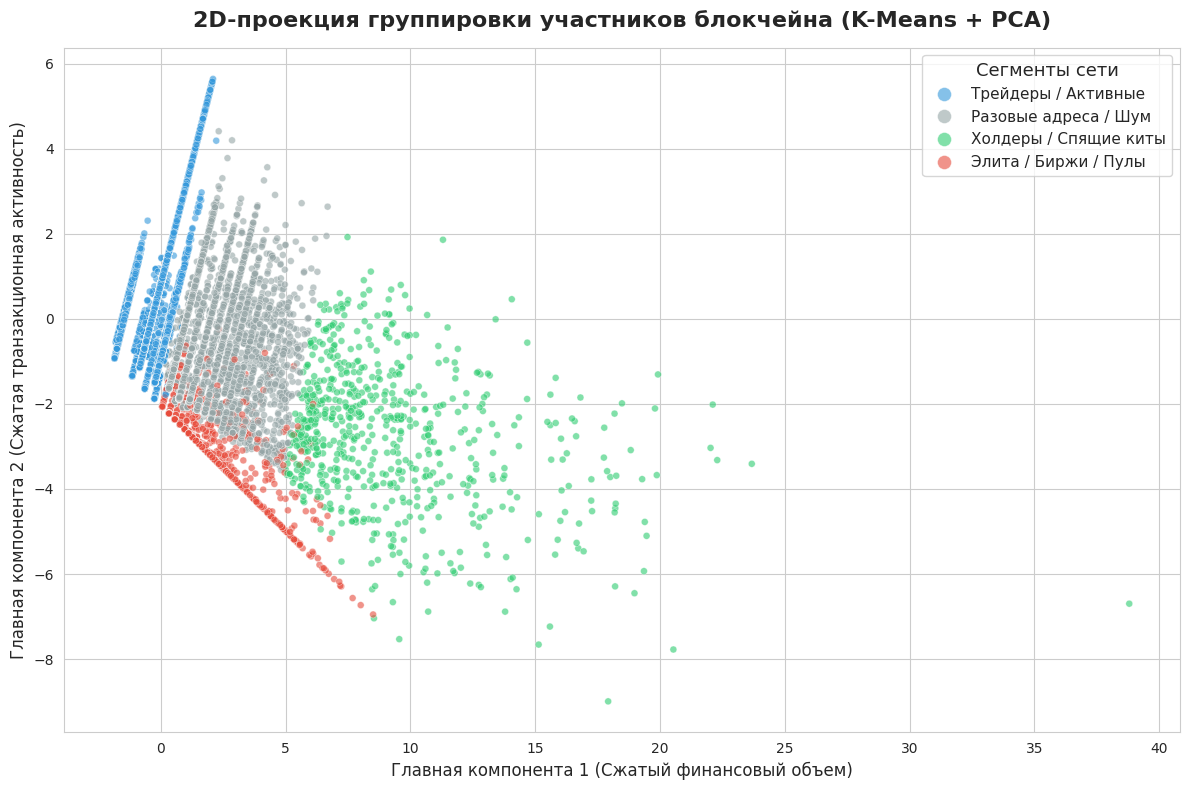

In [23]:
import cupy as cp
import cudf
import pandas as pd
from cuml.preprocessing import StandardScaler
from cuml.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("Готовим данные для визуализации...")
start_time = time.time()

features = ['Total_Received_BTC', 'Num_Receives', 'Total_Spent_BTC', 'Num_Spends', 'Total_Tx']
X_viz = user_profiles[features].copy()

for col in features:
    X_viz[col] = cp.log1p(X_viz[col])

scaler_viz = StandardScaler()
X_viz_scaled = scaler_viz.fit_transform(X_viz)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_viz_scaled)

if hasattr(pca_result, 'to_numpy'):
    pca_array = pca_result.to_numpy()
elif hasattr(pca_result, 'get'):
    pca_array = pca_result.get()
else:
    pca_array = pca_result

df_pca = pd.DataFrame(pca_array, columns=['PC1', 'PC2'])

df_pca['Cluster'] = user_profiles['Cluster'].to_pandas().reset_index(drop=True)

df_plot = df_pca.sample(n=50000, random_state=42)

end_time = time.time()
print(f"Данные сжаты и готовы за {round(end_time - start_time, 2)} секунд. Рисуем график...\n")

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

cluster_names = {
    3: 'Элита / Биржи / Пулы',
    0: 'Трейдеры / Активные',
    1: 'Холдеры / Спящие киты',
    2: 'Разовые адреса / Шум'
}
df_plot['Тип пользователя'] = df_plot['Cluster'].map(cluster_names)

palette = {
    'Элита / Биржи / Пулы': '#e74c3c',    # Красный
    'Трейдеры / Активные': '#3498db',     # Синий
    'Холдеры / Спящие киты': '#2ecc71',   # Зеленый
    'Разовые адреса / Шум': '#95a5a6'     # Серый
}

sns.scatterplot(
    x='PC1', y='PC2',
    hue='Тип пользователя',
    palette=palette,
    data=df_plot,
    alpha=0.6,
    s=25
)

plt.title('2D-проекция группировки участников блокчейна (K-Means + PCA)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Главная компонента 1 (Сжатый финансовый объем)', fontsize=12)
plt.ylabel('Главная компонента 2 (Сжатая транзакционная активность)', fontsize=12)
plt.legend(title='Сегменты сети', title_fontsize='13', fontsize='11', markerscale=2, loc='best')

plt.tight_layout()
plt.show()

In [24]:
import cupy as cp
import cudf
import pandas as pd
from cuml.preprocessing import StandardScaler
from cuml.decomposition import PCA
import plotly.express as px
import time

print("Готовим интерактивное 3D-пространство...")
start_time = time.time()

features = ['Total_Received_BTC', 'Num_Receives', 'Total_Spent_BTC', 'Num_Spends', 'Total_Tx']
X_viz = user_profiles[features].copy()

for col in features:
    X_viz[col] = cp.log1p(X_viz[col])

scaler_viz = StandardScaler()
X_viz_scaled = scaler_viz.fit_transform(X_viz)

pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_viz_scaled)

if hasattr(pca_result, 'to_numpy'):
    pca_array = pca_result.to_numpy()
elif hasattr(pca_result, 'get'):
    pca_array = pca_result.get()
else:
    pca_array = pca_result

df_pca = pd.DataFrame(pca_array, columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster'] = user_profiles['Cluster'].to_pandas().reset_index(drop=True)

df_plot = df_pca.sample(n=30000, random_state=42)

cluster_names = {
    3: 'Элита / Биржи / Пулы',
    0: 'Трейдеры / Активные',
    1: 'Холдеры / Спящие киты',
    2: 'Разовые адреса / Шум'
}
df_plot['Тип пользователя'] = df_plot['Cluster'].map(cluster_names)

color_map = {
    'Элита / Биржи / Пулы': '#e74c3c',
    'Трейдеры / Активные': '#3498db',
    'Холдеры / Спящие киты': '#2ecc71',
    'Разовые адреса / Шум': '#95a5a6'
}

end_time = time.time()
print(f"✅ Данные готовы за {round(end_time - start_time, 2)} секунд. Рендерим 3D...\n")

fig = px.scatter_3d(
    df_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Тип пользователя',
    color_discrete_map=color_map,
    opacity=0.7,
    title='3D-сегментация участников блокчейна (PCA: 3 Компоненты)'
)

fig.update_traces(marker=dict(size=3))

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

fig.show()

Готовим интерактивное 3D-пространство...
✅ Данные готовы за 1.35 секунд. Рендерим 3D...



In [25]:
from google.colab import files

print("Сохраняем финальный датасет...")

user_profiles.to_pandas().to_csv('bitcoin_clustered_users.csv', index=False)

files.download('bitcoin_clustered_users.csv')
print("Файл 'bitcoin_clustered_users.csv' отправлен на скачивание!")

Сохраняем финальный датасет...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл 'bitcoin_clustered_users.csv' отправлен на скачивание!
